<a href="https://colab.research.google.com/github/RealGoldenGeneral/SmartVerify-Take-Home-Assignment/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extended Dataset Analysis
Before creating the pipeline, we would need to understand both schemas. In this dataset analysis we are looking for class imbalance, outliers, and data types. This analysis will be important when analyzing features to input to the model.

In [24]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Load datasets
df_query = pd.read_csv("../data/query_events.csv")
df_sessions = pd.read_csv("../data/sessions.csv")

print("Size of query events dataset:", len(df_query))
print("Size of sessions dataset:", len(df_sessions))

print("Columns of query events dataset:", df_query.columns)
print("Columns of sessions dataset:", df_sessions.columns)

Size of query events dataset: 3309
Size of sessions dataset: 230
Columns of query events dataset: Index(['session_id', 'timestamp', 'enterprise_id', 'user_id', 'agent_id',
       'query_text', 'query_type', 'table_or_tables_accessed', 'row_estimate',
       'model_confidence', 'intent', 'status_code'],
      dtype='object')
Columns of sessions dataset: Index(['session_id', 'enterprise_id', 'user_id', 'agent_id', 'agent_type',
       'user_role', 'start_time', 'end_time', 'duration_seconds', 'num_events',
       'declared_intent', 'is_anomalous_session', 'slow_drip_exfiltration',
       'broad_retrieval_or_table_scan', 'intent_drift',
       'privilege_escalation_or_sensitive_access_violation',
       'high_entropy_exploration',
       'off_hours_sensitive_or_high_volume_access'],
      dtype='object')


In [26]:
df_query.head()

,session_id,timestamp,enterprise_id,user_id,agent_id,query_text,query_type,table_or_tables_accessed,row_estimate,model_confidence,intent,status_code
0,sess_1000,2026-05-17 07:49:19,ent_nexus_beta,usr_500,agt_6,"SELECT warehouse, updated_at FROM inventory WH...",SELECT,inventory,2320,0.8844,inventory_check,200
1,sess_1000,2026-05-17 08:03:35,ent_nexus_beta,usr_500,agt_6,"SELECT sku, AVG(amount) FROM inventory GROUP B...",AGGREGATION,inventory,5493,0.8811,inventory_check,200
2,sess_1000,2026-05-17 08:05:12,ent_nexus_beta,usr_500,agt_6,"SELECT sku, MAX(id) FROM inventory GROUP BY sku",AGGREGATION,inventory,8967,0.6200,inventory_check,200
3,sess_1000,2026-05-17 08:05:21,ent_nexus_beta,usr_500,agt_6,"SELECT id, category FROM products WHERE id = 4777",SELECT,products,241,0.8277,inventory_check,200
4,sess_1000,2026-05-17 08:14:52,ent_nexus_beta,usr_500,agt_6,"SELECT products.id, inventory.id FROM products...",JOIN,"products,inventory",88,0.7737,inventory_check,200


In [27]:
df_sessions.head()

,session_id,enterprise_id,user_id,agent_id,agent_type,user_role,start_time,end_time,duration_seconds,num_events,declared_intent,is_anomalous_session,slow_drip_exfiltration,broad_retrieval_or_table_scan,intent_drift,privilege_escalation_or_sensitive_access_violation,high_entropy_exploration,off_hours_sensitive_or_high_volume_access
0,sess_1000,ent_nexus_beta,usr_500,agt_6,automated_cron,analyst,2026-05-17 07:47:53,2026-05-17 08:25:43,2270,13,inventory_check,0,0,0,0,0,0,0
1,sess_1001,ent_corp_alpha,usr_501,agt_2,internal_tool,admin,2026-05-07 19:54:19,2026-05-07 20:22:05,1666,15,system_health_check,0,0,0,0,0,0,0
2,sess_1002,ent_nexus_beta,usr_502,agt_6,user_facing_llm,analyst,2026-05-12 17:35:46,2026-05-12 17:59:21,1415,17,billing_summary,0,0,0,0,0,0,0
3,sess_1003,ent_corp_alpha,usr_503,agt_6,user_facing_llm,support,2026-05-20 15:15:01,2026-05-20 16:01:57,2816,20,order_management,0,0,0,0,0,0,0
4,sess_1004,ent_corp_alpha,usr_504,agt_11,internal_tool,admin,2026-05-19 12:20:54,2026-05-19 12:53:01,1927,14,report_generation,0,0,0,0,0,0,0


In [28]:
df_query.info()

df_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   session_id                3309 non-null   object 
 1   timestamp                 3309 non-null   object 
 2   enterprise_id             3309 non-null   object 
 3   user_id                   3309 non-null   object 
 4   agent_id                  3309 non-null   object 
 5   query_text                3309 non-null   object 
 6   query_type                3309 non-null   object 
 7   table_or_tables_accessed  3309 non-null   object 
 8   row_estimate              3309 non-null   int64  
 9   model_confidence          3309 non-null   float64
 10  intent                    3309 non-null   object 
 11  status_code               3309 non-null   int64  
dtypes: float64(1), int64(2), object(9)
memory usage: 310.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entri

In [29]:
df_query.describe()

,row_estimate,model_confidence,status_code
count,3309.000000,3309.000000,3309.000000
mean,2948.741009,0.837657,209.696585
std,13033.965041,0.133519,49.464586
min,10.000000,0.300000,200.000000
25%,172.000000,0.762000,200.000000
50%,578.000000,0.863200,200.000000
75%,2093.000000,0.941600,200.000000
max,373919.000000,0.995000,500.000000


In [30]:
df_sessions.describe()

,duration_seconds,num_events,is_anomalous_session,slow_drip_exfiltration,broad_retrieval_or_table_scan,intent_drift,privilege_escalation_or_sensitive_access_violation,high_entropy_exploration,off_hours_sensitive_or_high_volume_access
count,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000
mean,1768.508696,14.386957,0.221739,0.047826,0.043478,0.056522,0.056522,0.034783,0.034783
std,1652.860867,6.013290,0.416323,0.213864,0.204376,0.231430,0.231430,0.183628,0.183628
min,458.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1089.750000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1403.500000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1769.500000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10111.000000,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Feature Distribution

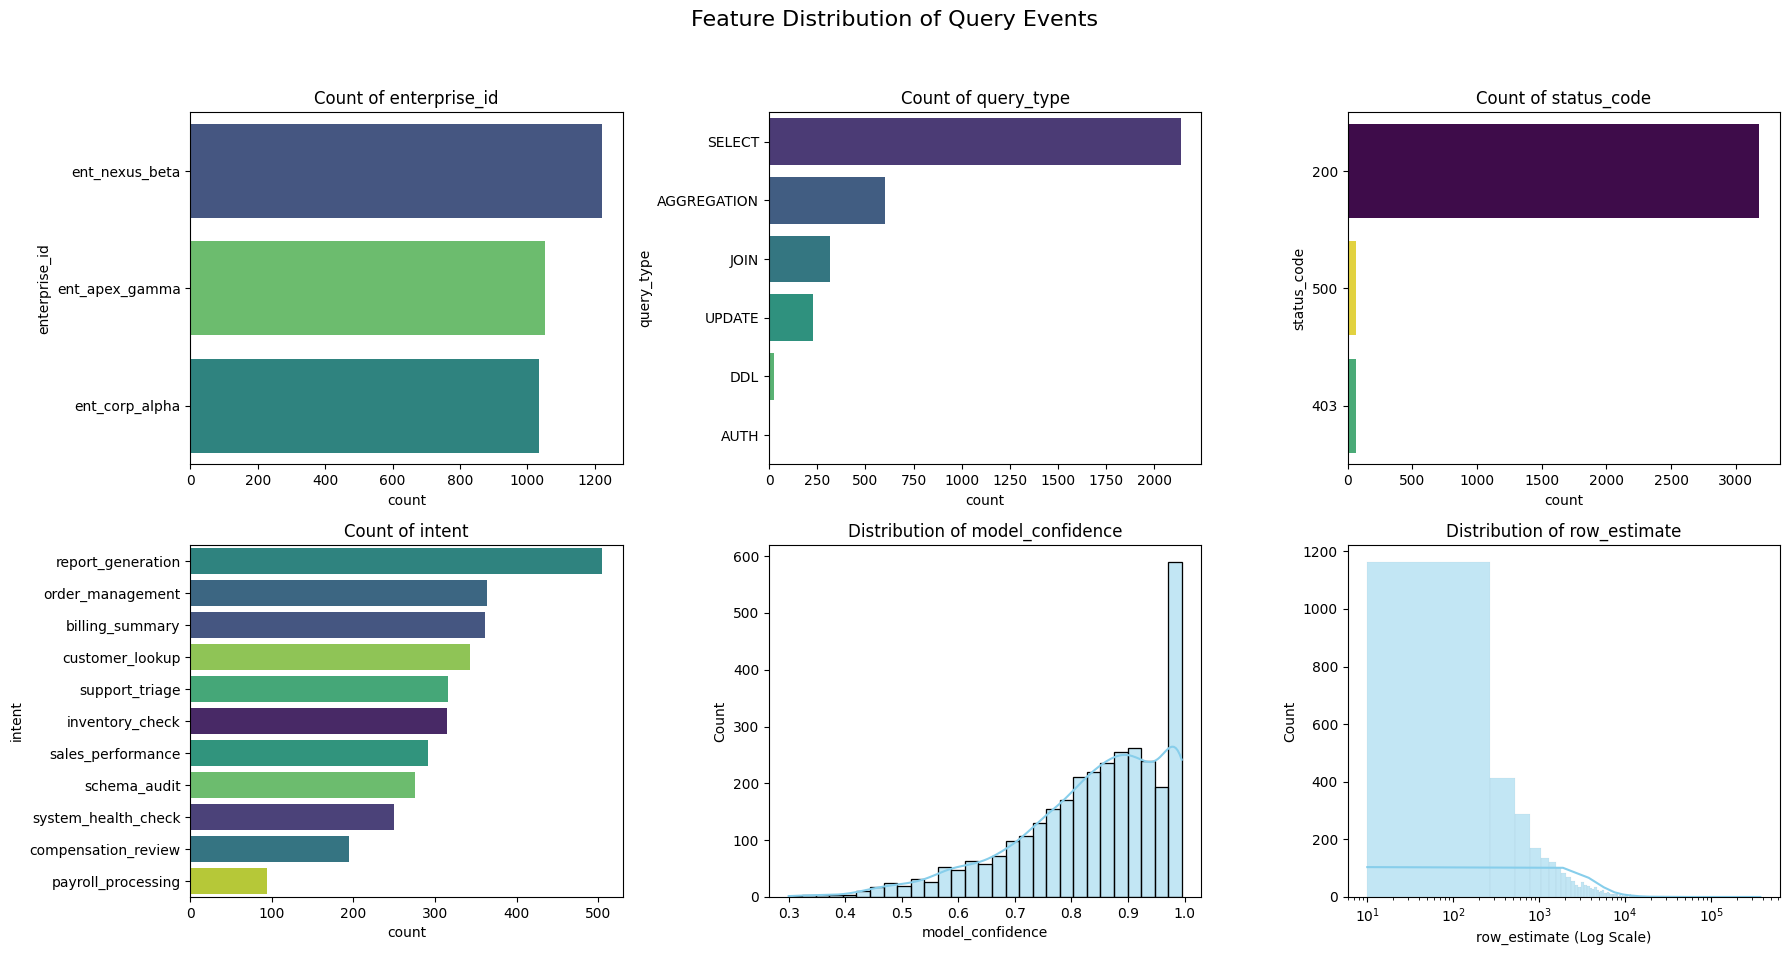

In [31]:
# Cleaned Feature Distribution of Query Events
cols_to_plot = [
    'enterprise_id', 'query_type', 'status_code',
    'intent', 'model_confidence', 'row_estimate'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle('Feature Distribution of Query Events', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if df_query[col].dtype == 'object' or df_query[col].nunique() < 15:
        # Categorical or low-cardinality numerical
        sns.countplot(
            data=df_query,
            y=col,
            ax=axes[i],
            order=df_query[col].value_counts().index,
            palette='viridis',
            hue=col,
            legend=False
        )
        axes[i].set_title(f'Count of {col}')
    else:
        # Numerical
        sns.histplot(df_query[col], ax=axes[i], kde=True, color='skyblue')
        axes[i].set_title(f'Distribution of {col}')
        if col == 'row_estimate':
            axes[i].set_xscale('log')
            axes[i].set_xlabel('row_estimate (Log Scale)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

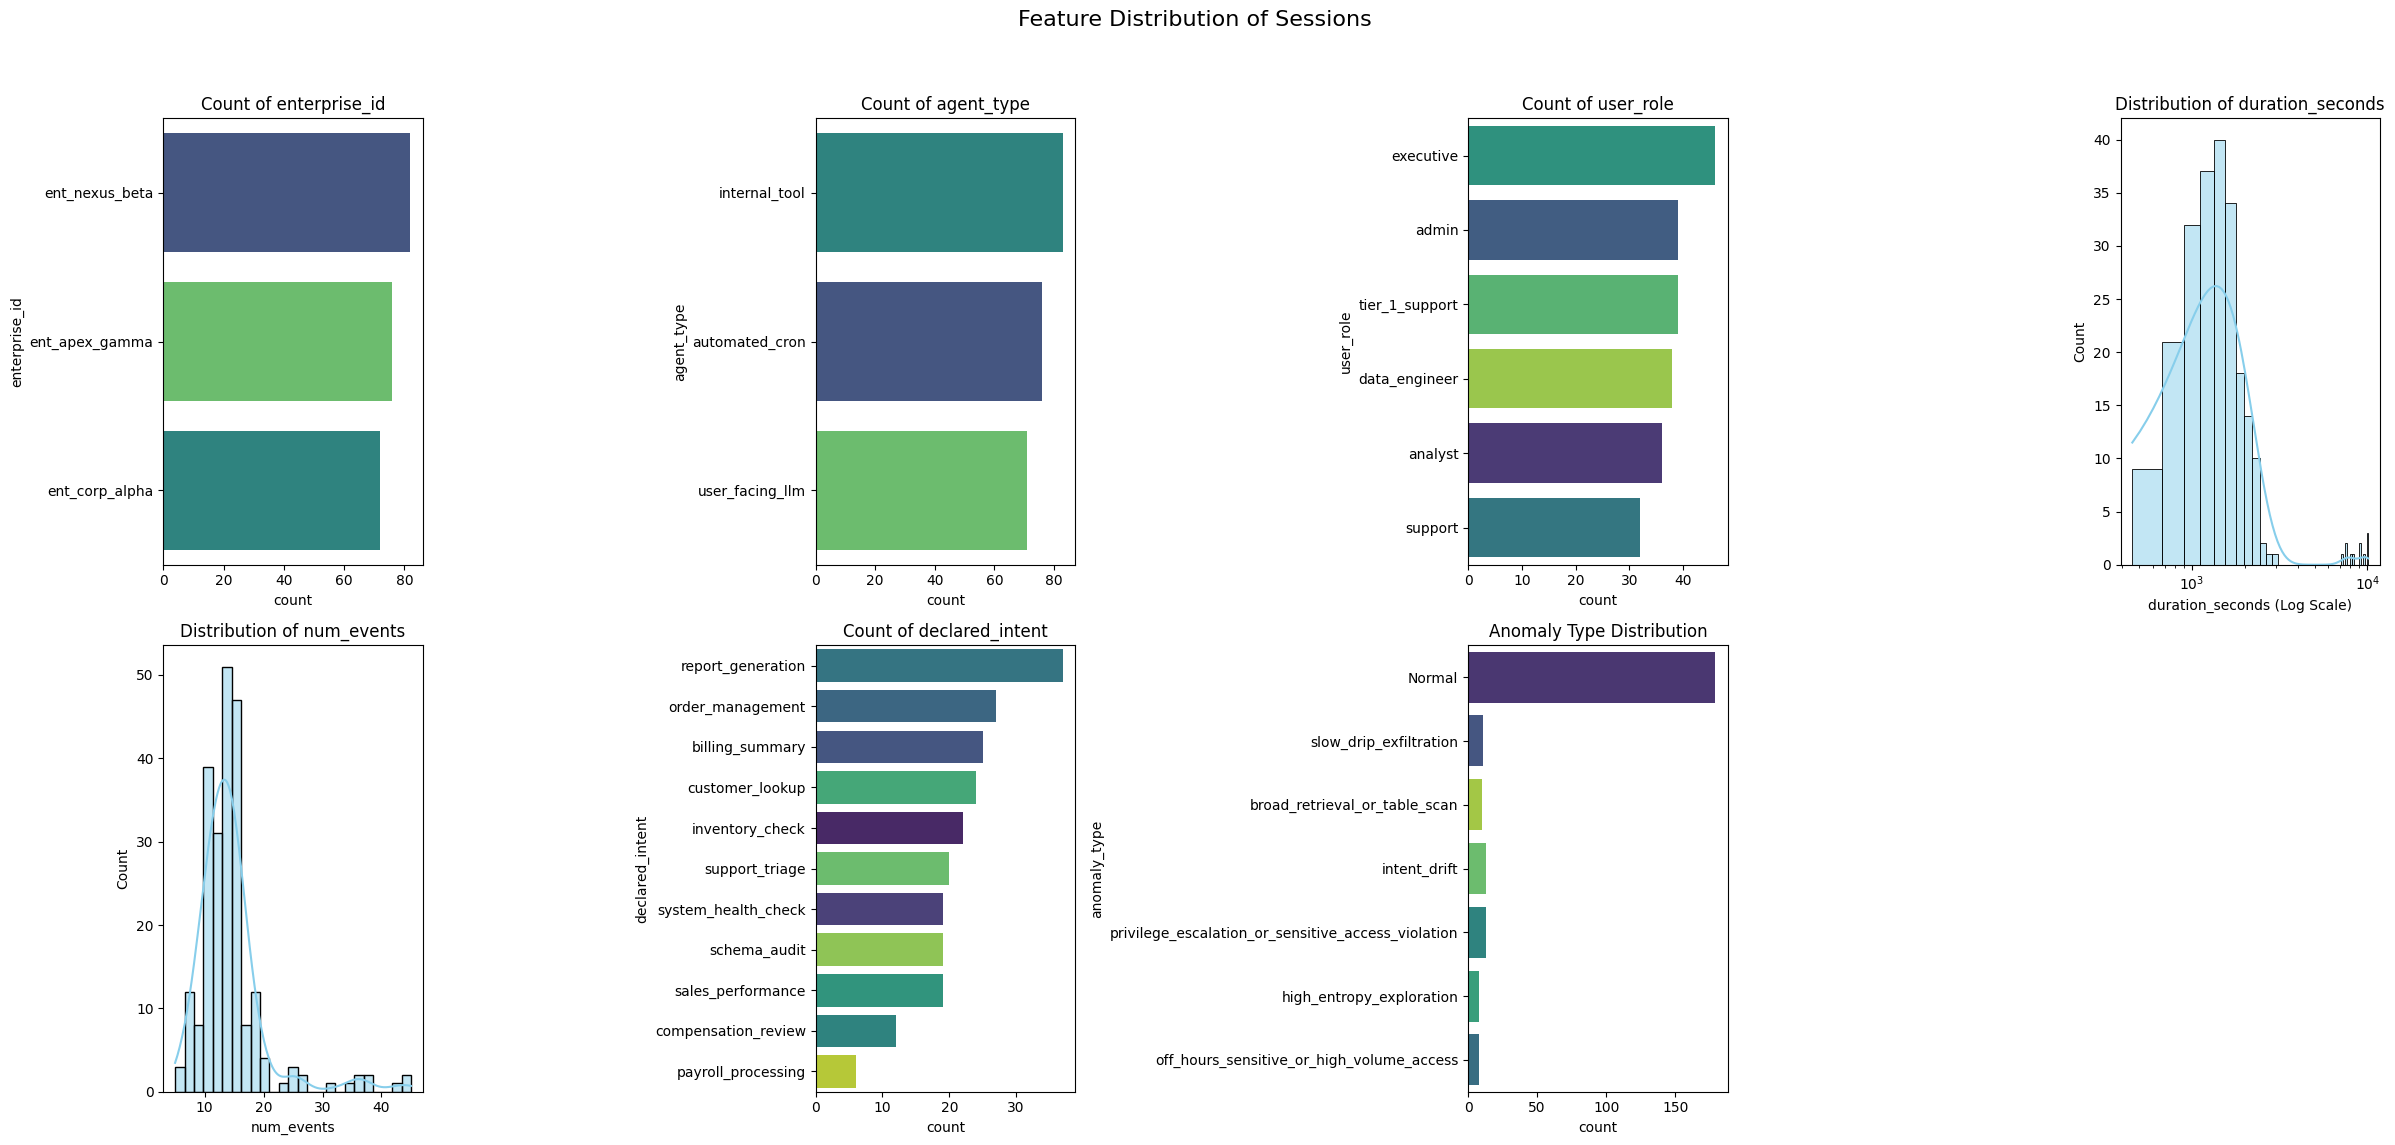

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Feature Distribution of Sessions
cols_to_plot = [
    'enterprise_id', 'agent_type', 'user_role',
    'duration_seconds', 'num_events', 'declared_intent',
]

anomaly_labels = ['slow_drip_exfiltration', 'broad_retrieval_or_table_scan',
                  'intent_drift', 'privilege_escalation_or_sensitive_access_violation',
                  'high_entropy_exploration', 'off_hours_sensitive_or_high_volume_access']

anomaly_type = []
for idx, row in df_sessions.iterrows():
    if row['is_anomalous_session'] == 0:
        anomaly_type.append('Normal')
    else:
        found = False
        for label in anomaly_labels:
            if row[label] == 1:
                anomaly_type.append(label)
                found = True
        if not found:
            anomaly_type.append('Unknown Anomaly')

plot_list = cols_to_plot + ['anomaly_type']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 12))
fig.suptitle('Feature Distribution of Sessions', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(plot_list):
    if col == 'anomaly_type':
        all_possible_labels = ['Normal'] + anomaly_labels
        sns.countplot(
            data=pd.DataFrame({'anomaly_type': anomaly_type}),
            y=col,
            ax=axes[i],
            order=all_possible_labels,
            palette='viridis',
            hue=col,
            legend=False
        )
        axes[i].set_title('Anomaly Type Distribution')
    elif df_sessions[col].dtype == 'object' or df_sessions[col].nunique() < 15:
        sns.countplot(
            data=df_sessions,
            y=col,
            ax=axes[i],
            order=df_sessions[col].value_counts().index,
            palette='viridis',
            hue=col,
            legend=False
        )
        axes[i].set_title(f'Count of {col}')
    else:
        sns.histplot(df_sessions[col], ax=axes[i], kde=True, color='skyblue')
        axes[i].set_title(f'Distribution of {col}')
        if col == 'duration_seconds':
            axes[i].set_xscale('log')
            axes[i].set_xlabel('duration_seconds (Log Scale)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Feature Engineering
This section of the assignment covers both session-level and sequence-level features.

## Query count
The 'num_events' columns in the sessions dataset covers this feature perfectly as grouping every query with the session id results in the same numbers as the 'num-events' column.

## Unique tables accessed
Since a query can access up to 2 tables at a time with the "JOIN" query, we split all join tables accessed into 2 rows for each table. We then count the number of unique tables accessed for every query in a session and create a column with these numbers.

In [33]:
# Unique tables accessed
df_query['table_list'] = df_query['table_or_tables_accessed'].str.split(',')

# Count unique tables per session
df_unique_tables_accessed = (
    df_query.explode('table_list')
    .groupby('session_id')['table_list']
    .nunique()
    .reset_index(name='unique_tables_accessed')
)

# Merge and clean up
df_sessions = df_sessions.merge(df_unique_tables_accessed, on='session_id', how='left')
df_sessions['unique_tables_accessed'] = df_sessions['unique_tables_accessed'].fillna(0).astype(int)

df_sessions.head()

,session_id,enterprise_id,user_id,agent_id,agent_type,user_role,start_time,end_time,duration_seconds,num_events,declared_intent,is_anomalous_session,slow_drip_exfiltration,broad_retrieval_or_table_scan,intent_drift,privilege_escalation_or_sensitive_access_violation,high_entropy_exploration,off_hours_sensitive_or_high_volume_access,unique_tables_accessed
0,sess_1000,ent_nexus_beta,usr_500,agt_6,automated_cron,analyst,2026-05-17 07:47:53,2026-05-17 08:25:43,2270,13,inventory_check,0,0,0,0,0,0,0,2
1,sess_1001,ent_corp_alpha,usr_501,agt_2,internal_tool,admin,2026-05-07 19:54:19,2026-05-07 20:22:05,1666,15,system_health_check,0,0,0,0,0,0,0,3
2,sess_1002,ent_nexus_beta,usr_502,agt_6,user_facing_llm,analyst,2026-05-12 17:35:46,2026-05-12 17:59:21,1415,17,billing_summary,0,0,0,0,0,0,0,3
3,sess_1003,ent_corp_alpha,usr_503,agt_6,user_facing_llm,support,2026-05-20 15:15:01,2026-05-20 16:01:57,2816,20,order_management,0,0,0,0,0,0,0,3
4,sess_1004,ent_corp_alpha,usr_504,agt_11,internal_tool,admin,2026-05-19 12:20:54,2026-05-19 12:53:01,1927,14,report_generation,0,0,0,0,0,0,0,4


## Cross-table join count
This count is achieved by grouping every query with the JOIN type by session ID and listing the size of the group.

In [34]:
# Cross-table join count
df_cross_table_join_count = (
    df_query[df_query['query_type'] == 'JOIN']
    .groupby('session_id')
    .size()
    .reset_index(name='cross_table_join_count')
)

df_sessions = df_sessions.merge(df_cross_table_join_count, on='session_id', how='left')
df_sessions['cross_table_join_count'] = df_sessions['cross_table_join_count'].fillna(0).astype(int)

df_sessions.head()

,session_id,enterprise_id,user_id,agent_id,agent_type,user_role,start_time,end_time,duration_seconds,num_events,declared_intent,is_anomalous_session,slow_drip_exfiltration,broad_retrieval_or_table_scan,intent_drift,privilege_escalation_or_sensitive_access_violation,high_entropy_exploration,off_hours_sensitive_or_high_volume_access,unique_tables_accessed,cross_table_join_count
0,sess_1000,ent_nexus_beta,usr_500,agt_6,automated_cron,analyst,2026-05-17 07:47:53,2026-05-17 08:25:43,2270,13,inventory_check,0,0,0,0,0,0,0,2,1
1,sess_1001,ent_corp_alpha,usr_501,agt_2,internal_tool,admin,2026-05-07 19:54:19,2026-05-07 20:22:05,1666,15,system_health_check,0,0,0,0,0,0,0,3,3
2,sess_1002,ent_nexus_beta,usr_502,agt_6,user_facing_llm,analyst,2026-05-12 17:35:46,2026-05-12 17:59:21,1415,17,billing_summary,0,0,0,0,0,0,0,3,2
3,sess_1003,ent_corp_alpha,usr_503,agt_6,user_facing_llm,support,2026-05-20 15:15:01,2026-05-20 16:01:57,2816,20,order_management,0,0,0,0,0,0,0,3,0
4,sess_1004,ent_corp_alpha,usr_504,agt_11,internal_tool,admin,2026-05-19 12:20:54,2026-05-19 12:53:01,1927,14,report_generation,0,0,0,0,0,0,0,4,2


## Entropy or diversity of table-access sequence
We calculate the entropy of the sequence by using the formula ∑p log (1/p). The probabilities are calculated by grouping every table accessed and acquiring the number of events for each session id and dividing the number of queries accessing the specific table with the amount of queries for the session id.

In [35]:
# Entropy or diversity of table-access sequence
df_tables_accessed = (
    df_query.explode('table_list')
    .groupby('session_id')['table_list']
    .value_counts()
    .reset_index()
)

for idx, row in df_sessions.iterrows():
    entropy = 0
    session_id = row['session_id']
    total_queries = row['num_events']
    tables_accessed = df_tables_accessed[df_tables_accessed['session_id'] == session_id]
    for idx2, count in enumerate(tables_accessed['count']):
      entropy += (count / total_queries) * np.log2(total_queries / count)
    df_sessions.at[idx, 'entropy_table_access_sequence'] = entropy

df_sessions.head()

,session_id,enterprise_id,user_id,agent_id,agent_type,user_role,start_time,end_time,duration_seconds,num_events,...,is_anomalous_session,slow_drip_exfiltration,broad_retrieval_or_table_scan,intent_drift,privilege_escalation_or_sensitive_access_violation,high_entropy_exploration,off_hours_sensitive_or_high_volume_access,unique_tables_accessed,cross_table_join_count,entropy_table_access_sequence
0,sess_1000,ent_nexus_beta,usr_500,agt_6,automated_cron,analyst,2026-05-17 07:47:53,2026-05-17 08:25:43,2270,13,...,0,0,0,0,0,0,0,2,1,0.814375
1,sess_1001,ent_corp_alpha,usr_501,agt_2,internal_tool,admin,2026-05-07 19:54:19,2026-05-07 20:22:05,1666,15,...,0,0,0,0,0,0,0,3,3,1.406983
2,sess_1002,ent_nexus_beta,usr_502,agt_6,user_facing_llm,analyst,2026-05-12 17:35:46,2026-05-12 17:59:21,1415,17,...,0,0,0,0,0,0,0,3,2,1.507217
3,sess_1003,ent_corp_alpha,usr_503,agt_6,user_facing_llm,support,2026-05-20 15:15:01,2026-05-20 16:01:57,2816,20,...,0,0,0,0,0,0,0,3,0,1.521928
4,sess_1004,ent_corp_alpha,usr_504,agt_11,internal_tool,admin,2026-05-19 12:20:54,2026-05-19 12:53:01,1927,14,...,0,0,0,0,0,0,0,4,2,1.893665


## Time deltas
Time deltas are acquired by subtracting the difference between the timestamps of the queries. The first timestamp of a session will always have a time delta of 0.

In [36]:
# Time deltas
df_query['timestamp'] = pd.to_datetime(df_query['timestamp'])

df_query = df_query.sort_values(by=['session_id', 'timestamp'])

df_query['time_delta'] = df_query.groupby('session_id')['timestamp'].diff()

df_query['time_delta'] = df_query['time_delta'].fillna(pd.Timedelta(seconds=0))

df_query['time_delta'] = df_query['time_delta'].dt.total_seconds()

df_query.head()

,session_id,timestamp,enterprise_id,user_id,agent_id,query_text,query_type,table_or_tables_accessed,row_estimate,model_confidence,intent,status_code,table_list,time_delta
0,sess_1000,2026-05-17 07:49:19,ent_nexus_beta,usr_500,agt_6,"SELECT warehouse, updated_at FROM inventory WH...",SELECT,inventory,2320,0.8844,inventory_check,200,[inventory],0.0
1,sess_1000,2026-05-17 08:03:35,ent_nexus_beta,usr_500,agt_6,"SELECT sku, AVG(amount) FROM inventory GROUP B...",AGGREGATION,inventory,5493,0.8811,inventory_check,200,[inventory],856.0
2,sess_1000,2026-05-17 08:05:12,ent_nexus_beta,usr_500,agt_6,"SELECT sku, MAX(id) FROM inventory GROUP BY sku",AGGREGATION,inventory,8967,0.6200,inventory_check,200,[inventory],97.0
3,sess_1000,2026-05-17 08:05:21,ent_nexus_beta,usr_500,agt_6,"SELECT id, category FROM products WHERE id = 4777",SELECT,products,241,0.8277,inventory_check,200,[products],9.0
4,sess_1000,2026-05-17 08:14:52,ent_nexus_beta,usr_500,agt_6,"SELECT products.id, inventory.id FROM products...",JOIN,"products,inventory",88,0.7737,inventory_check,200,"[products, inventory]",571.0


### Summary Statistics
Summary statistics for time deltas are the mean, standard distribution, minimum, and maximum time delta for each session.

In [37]:
# Time delta summary statistics
df_time_delta_stats = (
    df_query.groupby('session_id')['time_delta']
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
)

df_time_delta_stats.columns = ['session_id', 'time_delta_mean', 'time_delta_std', 'time_delta_min', 'time_delta_max']

df_sessions = df_sessions.merge(df_time_delta_stats, on='session_id', how='left')

df_sessions.head()

,session_id,enterprise_id,user_id,agent_id,agent_type,user_role,start_time,end_time,duration_seconds,num_events,...,privilege_escalation_or_sensitive_access_violation,high_entropy_exploration,off_hours_sensitive_or_high_volume_access,unique_tables_accessed,cross_table_join_count,entropy_table_access_sequence,time_delta_mean,time_delta_std,time_delta_min,time_delta_max
0,sess_1000,ent_nexus_beta,usr_500,agt_6,automated_cron,analyst,2026-05-17 07:47:53,2026-05-17 08:25:43,2270,13,...,0,0,0,2,1,0.814375,168.000000,256.014648,0.0,856.0
1,sess_1001,ent_corp_alpha,usr_501,agt_2,internal_tool,admin,2026-05-07 19:54:19,2026-05-07 20:22:05,1666,15,...,0,0,0,3,3,1.406983,104.800000,82.086366,0.0,307.0
2,sess_1002,ent_nexus_beta,usr_502,agt_6,user_facing_llm,analyst,2026-05-12 17:35:46,2026-05-12 17:59:21,1415,17,...,0,0,0,3,2,1.507217,71.294118,72.675447,0.0,286.0
3,sess_1003,ent_corp_alpha,usr_503,agt_6,user_facing_llm,support,2026-05-20 15:15:01,2026-05-20 16:01:57,2816,20,...,0,0,0,3,0,1.521928,138.150000,117.908205,0.0,357.0
4,sess_1004,ent_corp_alpha,usr_504,agt_11,internal_tool,admin,2026-05-19 12:20:54,2026-05-19 12:53:01,1927,14,...,0,0,0,4,2,1.893665,126.785714,115.725257,0.0,373.0


Summary statistics for confidence scores are mean, standard deviation, minimum, and maximum for each session id.

In [38]:
# Confidence score summary statistics
df_confidence_stats = (
    df_query.groupby('session_id')['model_confidence']
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
)

df_confidence_stats.columns = ['session_id', 'confidence_mean', 'confidence_std', 'confidence_min', 'confidence_max']

df_sessions = df_sessions.merge(df_confidence_stats, on='session_id', how='left')

df_sessions.head()

,session_id,enterprise_id,user_id,agent_id,agent_type,user_role,start_time,end_time,duration_seconds,num_events,...,cross_table_join_count,entropy_table_access_sequence,time_delta_mean,time_delta_std,time_delta_min,time_delta_max,confidence_mean,confidence_std,confidence_min,confidence_max
0,sess_1000,ent_nexus_beta,usr_500,agt_6,automated_cron,analyst,2026-05-17 07:47:53,2026-05-17 08:25:43,2270,13,...,1,0.814375,168.000000,256.014648,0.0,856.0,0.842531,0.108996,0.6200,0.995
1,sess_1001,ent_corp_alpha,usr_501,agt_2,internal_tool,admin,2026-05-07 19:54:19,2026-05-07 20:22:05,1666,15,...,3,1.406983,104.800000,82.086366,0.0,307.0,0.855240,0.095610,0.6249,0.995
2,sess_1002,ent_nexus_beta,usr_502,agt_6,user_facing_llm,analyst,2026-05-12 17:35:46,2026-05-12 17:59:21,1415,17,...,2,1.507217,71.294118,72.675447,0.0,286.0,0.884935,0.074845,0.6982,0.995
3,sess_1003,ent_corp_alpha,usr_503,agt_6,user_facing_llm,support,2026-05-20 15:15:01,2026-05-20 16:01:57,2816,20,...,0,1.521928,138.150000,117.908205,0.0,357.0,0.876050,0.079199,0.7528,0.995
4,sess_1004,ent_corp_alpha,usr_504,agt_11,internal_tool,admin,2026-05-19 12:20:54,2026-05-19 12:53:01,1927,14,...,2,1.893665,126.785714,115.725257,0.0,373.0,0.837971,0.110467,0.6926,0.995


## Intent drift score
Since every query intention have different definitions of anomalious behaviour, we will calculate intent drift score according to each query intent.

The general summary of the calculation of intent drift score is as such: The highest weight towards intent drift will be tables accessed. Tables accessed will be the most important features towards intent drift score because a query accessing a table different from the query's listed role is the most suspicious behaviour that a query can have. The second most important feature towards intent drift will be query type as sensitive access violations will try to use UPDATE commands. The third most important feature towards intent drift will be matching the intentions of the session with the query as intent drift queries will shift intentions mid-session. The final important feature will be row estimate as high row estimates can be signs of table scanning.

In [39]:
# Variables for intent score multipliers
USER_ROLES = {
    'executive' : {'inventory' : 1, 'products' : 1, 'information_schema.tables' : 1, 'page_views' : 1, 'information_schema.columns' : 1, 'logs' : 1, 'billing_records' : 1, 'orders' : 1, 'customers' : 1, 'shipments' : 1, 'employee_salaries' : 1, 'executive_compensation' : 1, 'support_tickets' : 1, 'audit_log' : 1, 'customer_pii' : 1, 'system_credentials' : 1, 'users' : 1},
    'admin' : {'inventory' : 1, 'products' : 1, 'information_schema.tables' : 1, 'page_views' : 1, 'information_schema.columns' : 1, 'logs' : 1, 'billing_records' : 1, 'orders' : 1, 'customers' : 1, 'shipments' : 1, 'employee_salaries' : 1, 'executive_compensation' : 1, 'support_tickets' : 1, 'audit_log' : 1, 'customer_pii' : 1, 'system_credentials' : 1, 'users' : 1},
    'analyst' : {'inventory' : 1, 'products' : 1, 'information_schema.tables' : 1, 'page_views' : 1, 'information_schema.columns' : 1, 'logs' : 1, 'billing_records' : 1, 'orders' : 1, 'customers' : 1, 'shipments' : 1, 'employee_salaries' : 2, 'executive_compensation' : 2, 'support_tickets' : 1, 'audit_log' : 2, 'customer_pii' : 2, 'system_credentials' : 2, 'users' : 2},
    'tier_1_support': {'inventory' : 1, 'products' : 1, 'information_schema.tables' : 1, 'page_views' : 1, 'information_schema.columns' : 1, 'logs' : 2, 'billing_records' : 1, 'orders' : 1, 'customers' : 1, 'shipments' : 1, 'employee_salaries' : 2, 'executive_compensation' : 2, 'support_tickets' : 1, 'audit_log' : 2, 'customer_pii' : 2, 'system_credentials' : 2, 'users' : 2},
    'data_engineer' : {'inventory' : 1, 'products' : 1, 'information_schema.tables' : 1, 'page_views' : 1, 'information_schema.columns' : 1, 'logs' : 1, 'billing_records' : 1, 'orders' : 1, 'customers' : 1, 'shipments' : 1, 'employee_salaries' : 1, 'executive_compensation' : 1, 'support_tickets' : 1, 'audit_log' : 1, 'customer_pii' : 2, 'system_credentials' : 2, 'users' : 1},
    'support' : {'inventory' : 1, 'products' : 1, 'information_schema.tables' : 1, 'page_views' : 1, 'information_schema.columns' : 1, 'logs' : 2, 'billing_records' : 1, 'orders' : 1, 'customers' : 1, 'shipments' : 1, 'employee_salaries' : 2, 'executive_compensation' : 2, 'support_tickets' : 1, 'audit_log' : 2, 'customer_pii' : 2, 'system_credentials' : 2, 'users' : 2}
}

INTENT = {
    'report_generation' : {'UPDATE' : 1, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'order_management' : {'UPDATE' : 1, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'billing_summary' : {'UPDATE' : 2, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'customer_lookup' : {'UPDATE' : 2, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'inventory_check' : {'UPDATE' : 1, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'support_triage' : {'UPDATE' : 1, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'system_health_check' : {'UPDATE' : 1, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'schema_audit' : {'UPDATE' : 1, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'sales_performance' : {'UPDATE' : 1, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'compensation_review' : {'UPDATE' : 2, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2},
    'payroll_processing' : {'UPDATE' : 1, 'SELECT' : 1, 'JOIN' : 1, 'AGGREGATION' : 1, 'DDL' : 2, 'AUTH': 2}
}

# Calculate intent drift scores
for idx, row in df_query.iterrows():
    session_info = df_sessions[df_sessions['session_id'] == row['session_id']].iloc[0]
    user_role = session_info['user_role']
    session_intent = session_info['declared_intent']
    events = session_info['num_events']

    user_role_multiplier = max([USER_ROLES[user_role].get(t.strip(), 1) for t in row['table_list']])

    intent_multiplier = INTENT[session_intent].get(row['query_type'], 1)
    intent_mismatch_multiplier = 2 if row['intent'] != session_intent else 1
    df_query.at[idx, 'intent_drift_score'] = user_role_multiplier * intent_multiplier * intent_mismatch_multiplier * np.log2(row['row_estimate']) / events

df_sessions_intent_drift_score = (
    df_query.groupby('session_id')['intent_drift_score']
    .sum()
    .reset_index(name='intent_drift_score')
)

# Avoid duplicate columns if running multiple times
if 'intent_drift_score' in df_sessions.columns:
    df_sessions = df_sessions.drop(columns=['intent_drift_score'])

df_sessions = df_sessions.merge(df_sessions_intent_drift_score, on='session_id', how='left')
display(df_sessions.head())

,session_id,enterprise_id,user_id,agent_id,agent_type,user_role,start_time,end_time,duration_seconds,num_events,...,entropy_table_access_sequence,time_delta_mean,time_delta_std,time_delta_min,time_delta_max,confidence_mean,confidence_std,confidence_min,confidence_max,intent_drift_score
0,sess_1000,ent_nexus_beta,usr_500,agt_6,automated_cron,analyst,2026-05-17 07:47:53,2026-05-17 08:25:43,2270,13,...,0.814375,168.000000,256.014648,0.0,856.0,0.842531,0.108996,0.6200,0.995,8.931782
1,sess_1001,ent_corp_alpha,usr_501,agt_2,internal_tool,admin,2026-05-07 19:54:19,2026-05-07 20:22:05,1666,15,...,1.406983,104.800000,82.086366,0.0,307.0,0.855240,0.095610,0.6249,0.995,10.335002
2,sess_1002,ent_nexus_beta,usr_502,agt_6,user_facing_llm,analyst,2026-05-12 17:35:46,2026-05-12 17:59:21,1415,17,...,1.507217,71.294118,72.675447,0.0,286.0,0.884935,0.074845,0.6982,0.995,9.812710
3,sess_1003,ent_corp_alpha,usr_503,agt_6,user_facing_llm,support,2026-05-20 15:15:01,2026-05-20 16:01:57,2816,20,...,1.521928,138.150000,117.908205,0.0,357.0,0.876050,0.079199,0.7528,0.995,10.691161
4,sess_1004,ent_corp_alpha,usr_504,agt_11,internal_tool,admin,2026-05-19 12:20:54,2026-05-19 12:53:01,1927,14,...,1.893665,126.785714,115.725257,0.0,373.0,0.837971,0.110467,0.6926,0.995,9.282293


The visualization below proves that the formula for intent drift identifies suspicious user activity by splitting all sessions by label. From this scatterplot we can summarize that anomalous sessions generally have higher intent drift score than their benign counterparts. The intent drift score also covers truly anomalous sessions as the scatter plot creates outliers of anomalous events beyond the cluster of normal events.

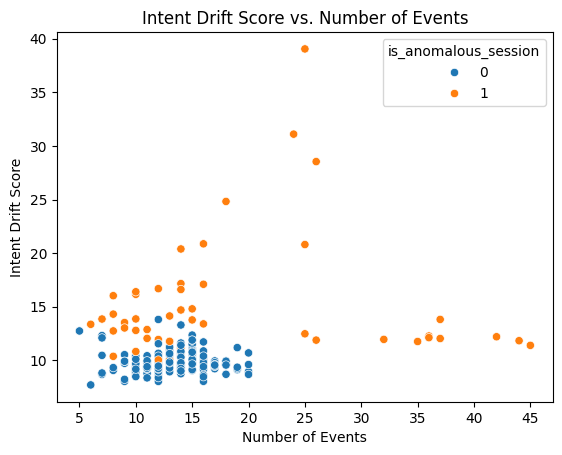

In [40]:
# Visualization proving that our intent drift score works
sns.scatterplot(data=df_sessions, x='num_events', y='intent_drift_score', hue='is_anomalous_session')
plt.title('Intent Drift Score vs. Number of Events')
plt.xlabel('Number of Events')
plt.ylabel('Intent Drift Score')
plt.show()

## Sensitive table access count
The amount of sensitive tables accessed in a session. Sensitive tables are defined as such by role:


*   Executive: None
*   Admin: None
*   Analyst: employee_salaries, executive_compensation, audit_log, customer_pii, system_credentials, users
*   Tier 1 Support: employee_salaries, executive_compensation, audit_log, customer_pii, system_credentials, users
*   Data Engineer: customer_pii, system_credentials
*   Support: employee_salaries, executive_compensation, audit_log, customer_pii, system_credentials, users



In [41]:
# Sensitive table access count mapping
SENSITIVE_TABLES = {
    'executive' : [],
    'admin' : [],
    'analyst' : ['employee_salaries', 'executive_compensation', 'audit_log', 'customer_pii', 'system_credentials', 'users'],
    'tier_1_support': ['employee_salaries', 'executive_compensation', 'audit_log', 'customer_pii', 'system_credentials', 'users'],
    'data_engineer' : ['customer_pii', 'system_credentials'],
    'support' : ['employee_salaries', 'executive_compensation', 'audit_log', 'customer_pii', 'system_credentials', 'users']
}

# Initialize the counter column
df_sessions['sensitive_table_access_count'] = 0

# Map roles to sessions for quick lookup in the query loop
role_map = df_sessions.set_index('session_id')['user_role'].to_dict()

# Calculate sensitive access counts from df_query
sensitive_counts = {}

for idx, row in df_query.iterrows():
    sid = row['session_id']
    role = role_map.get(sid)
    if role and role in SENSITIVE_TABLES:
        # Count how many tables in this query's table_list are sensitive for this role
        count = len([t.strip() for t in row['table_list'] if t.strip() in SENSITIVE_TABLES[role]])
        sensitive_counts[sid] = sensitive_counts.get(sid, 0) + count

# Map the results back to df_sessions
df_sessions['sensitive_table_access_count'] = df_sessions['session_id'].map(sensitive_counts).fillna(0).astype(int)

display(df_sessions[['session_id', 'user_role', 'sensitive_table_access_count']].head())

,session_id,user_role,sensitive_table_access_count
0,sess_1000,analyst,0
1,sess_1001,admin,0
2,sess_1002,analyst,0
3,sess_1003,support,0
4,sess_1004,admin,0


## Query type distribution
This feature is achieved by creating a column that counts the number of queries in a session that execute the command for each command type.

In [42]:
# Query type distribution feature
for idx, row in df_sessions.iterrows():
    sid = row['session_id']
    query_types = df_query[df_query['session_id'] == sid]['query_type'].value_counts().to_dict()
    for query_type, count in query_types.items():
        df_sessions.at[idx, f"{query_type.lower()}_count"] = count

df_sessions.fillna(0, inplace=True)

df_sessions.head()

,session_id,enterprise_id,user_id,agent_id,agent_type,user_role,start_time,end_time,duration_seconds,num_events,...,confidence_min,confidence_max,intent_drift_score,sensitive_table_access_count,select_count,aggregation_count,join_count,update_count,ddl_count,auth_count
0,sess_1000,ent_nexus_beta,usr_500,agt_6,automated_cron,analyst,2026-05-17 07:47:53,2026-05-17 08:25:43,2270,13,...,0.6200,0.995,8.931782,0,9.0,2.0,1.0,1.0,0.0,0.0
1,sess_1001,ent_corp_alpha,usr_501,agt_2,internal_tool,admin,2026-05-07 19:54:19,2026-05-07 20:22:05,1666,15,...,0.6249,0.995,10.335002,0,8.0,2.0,3.0,2.0,0.0,0.0
2,sess_1002,ent_nexus_beta,usr_502,agt_6,user_facing_llm,analyst,2026-05-12 17:35:46,2026-05-12 17:59:21,1415,17,...,0.6982,0.995,9.812710,0,14.0,1.0,2.0,0.0,0.0,0.0
3,sess_1003,ent_corp_alpha,usr_503,agt_6,user_facing_llm,support,2026-05-20 15:15:01,2026-05-20 16:01:57,2816,20,...,0.7528,0.995,10.691161,0,15.0,3.0,0.0,2.0,0.0,0.0
4,sess_1004,ent_corp_alpha,usr_504,agt_11,internal_tool,admin,2026-05-19 12:20:54,2026-05-19 12:53:01,1927,14,...,0.6926,0.995,9.282293,0,7.0,2.0,2.0,3.0,0.0,0.0


## Session Duration
Session duration is covered in the column duration_seconds.

## Sequence Features
To create features for sequential use, user_role and declared_intent will be one-hot encoded into the required features to create a hybrid representation of the session. The dataset will be split into 25 sessions per sequence. Each event will be represented by the user role, the duration of the event, the query types, the model confidence mean, the intent drift score, the entropy of the table access sequence, accessed table counts, including cross-table and sensitive-table access counts, the query count, and the time delta mean. Numberic fields will remain unchanged. No truncation, bucketing, or padding will be required to meet time constraints. The other labels are added into the dataset for analysis reasons.

In [43]:
# Create structured dataset for LSTM
COLUMNS = [
    'enterprise_id',
    'user_role',
    'duration_seconds',
    'num_events',
    'declared_intent',
    'is_anomalous_session',
    'slow_drip_exfiltration',
    'broad_retrieval_or_table_scan',
    'intent_drift',
    'privilege_escalation_or_sensitive_access_violation',
    'high_entropy_exploration',
    'unique_tables_accessed',
    'cross_table_join_count',
    'entropy_table_access_sequence',
    'time_delta_mean',
    'confidence_mean',
    'intent_drift_score',
    'sensitive_table_access_count',
    'select_count',
    'update_count',
    'join_count',
    'aggregation_count',
    'ddl_count',
    'auth_count'
]

df = df_sessions[COLUMNS]
df['user_role'] = df['user_role'].astype('category').cat.codes
df['declared_intent'] = df['declared_intent'].astype('category').cat.codes

df.head()

/tmp/ipykernel_2892/1986004341.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['user_role'] = df['user_role'].astype('category').cat.codes
/tmp/ipykernel_2892/1986004341.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['declared_intent'] = df['declared_intent'].astype('category').cat.codes


,enterprise_id,user_role,duration_seconds,num_events,declared_intent,is_anomalous_session,slow_drip_exfiltration,broad_retrieval_or_table_scan,intent_drift,privilege_escalation_or_sensitive_access_violation,...,time_delta_mean,confidence_mean,intent_drift_score,sensitive_table_access_count,select_count,update_count,join_count,aggregation_count,ddl_count,auth_count
0,ent_nexus_beta,1,2270,13,3,0,0,0,0,0,...,168.000000,0.842531,8.931782,0,9.0,1.0,1.0,2.0,0.0,0.0
1,ent_corp_alpha,0,1666,15,10,0,0,0,0,0,...,104.800000,0.855240,10.335002,0,8.0,2.0,3.0,2.0,0.0,0.0
2,ent_nexus_beta,1,1415,17,0,0,0,0,0,0,...,71.294118,0.884935,9.812710,0,14.0,0.0,2.0,1.0,0.0,0.0
3,ent_corp_alpha,4,2816,20,4,0,0,0,0,0,...,138.150000,0.876050,10.691161,0,15.0,2.0,0.0,3.0,0.0,0.0
4,ent_corp_alpha,0,1927,14,6,0,0,0,0,0,...,126.785714,0.837971,9.282293,0,7.0,3.0,2.0,2.0,0.0,0.0


In [44]:
df.to_csv("../data/sequences.csv")